In [1]:
import  panda as pd
import numpy as np



ModuleNotFoundError: No module named 'panda'

In [2]:
import pandas as pd


In [5]:
import numpy as np

#load your dataset
df=pd.read_csv('Employees_raw_data.csv')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            308 non-null    str    
 1   department          295 non-null    str    
 2   join_date           308 non-null    str    
 3   salary              290 non-null    float64
 4   age                 298 non-null    float64
 5   performance_rating  291 non-null    float64
 6   city                308 non-null    str    
 7   remote_work         281 non-null    str    
dtypes: float64(3), str(5)
memory usage: 19.4 KB


In [7]:
df.head()

,emp_name,department,join_date,salary,age,performance_rating,city,remote_work
0,Employee_1,Engineering,2018-01-01 00:00:00,60820.29,51.0,4.0,Pune,No
1,Employee_2,NaN,2018-01-08 20:04:01,48271.19,30.0,3.0,Delhi,No
2,Employee_3,HR,2018-01-16 16:08:02,98590.99,55.0,2.0,Mumbai,No
3,Employee_4,Marketing,2018-01-24 12:12:02,71410.54,56.0,3.0,Mumbai,No
4,Employee_5,Sales,2018-02-01 08:16:03,23547.43,43.0,4.0,Chennai,yes


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            308 non-null    str    
 1   department          295 non-null    str    
 2   join_date           308 non-null    str    
 3   salary              290 non-null    float64
 4   age                 298 non-null    float64
 5   performance_rating  291 non-null    float64
 6   city                308 non-null    str    
 7   remote_work         281 non-null    str    
dtypes: float64(3), str(5)
memory usage: 19.4 KB
None


In [9]:
df.isnull().sum()

emp_name               0
department            13
join_date              0
salary                18
age                   10
performance_rating    17
city                   0
remote_work           27
dtype: int64

In [13]:
#convert join date to datetime
df['join_date']=pd.to_datetime(df['join_date'])

In [16]:
#taking dates only from join_date
df['join_date_only']=df['join_date'].dt.date

In [21]:
#ensuring numeric columns values to be numeric(coercing to nan)
numeric_cols = ['salary', 'age', 'performance_rating']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [22]:
df.head()



,emp_name,department,join_date,salary,age,performance_rating,city,remote_work,join_date_only
0,Employee_1,Engineering,2018-01-01 00:00:00,60820.29,51.0,4.0,Pune,No,2018-01-01
1,Employee_2,NaN,2018-01-08 20:04:01,48271.19,30.0,3.0,Delhi,No,2018-01-08
2,Employee_3,HR,2018-01-16 16:08:02,98590.99,55.0,2.0,Mumbai,No,2018-01-16
3,Employee_4,Marketing,2018-01-24 12:12:02,71410.54,56.0,3.0,Mumbai,No,2018-01-24
4,Employee_5,Sales,2018-02-01 08:16:03,23547.43,43.0,4.0,Chennai,yes,2018-02-01


In [30]:
df.drop(columns=['join_date'], inplace=True)

KeyError: "['join_date'] not found in axis"

In [31]:
df.columns

Index(['emp_name', 'department', 'salary', 'age', 'performance_rating', 'city',
       'remote_work', 'join_date_only'],
      dtype='str')

In [35]:
#empty department column values need to be assigned,,but cant put median here will create irregularities
df['department']=df['department'].fillna('unknown')

In [39]:
#for empty salry column calues,put by grouping with department
df['salary']=df.groupby('department')['salary'].transform(lambda x:x.fillna(x.median()))

In [41]:
#for empty values in age column fill with median
df['age']=df['age'].fillna(df['age'].median()).astype(int)

In [42]:
#for empty values in performance_rating
df['performance_rating']=df['performance_rating'].fillna(df['performance_rating'].median())

In [43]:
# Strip accidental whitespace from strings
text_cols = ['emp_name', 'department', 'city']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Check unique categories for typos (e.g., 'pune' vs 'Pune')
print(df['city'].unique())
print(df['department'].unique())

# Validate logical bounds
assert df['age'].between(18, 70).all(), "Invalid age found"
assert df['performance_rating'].between(1, 5).all(), "Invalid rating found"
assert (df['salary'] > 0).all(), "Zero or negative salary found"

<StringArray>
['Pune', 'Delhi', 'Mumbai', 'Chennai', 'Bangalore']
Length: 5, dtype: str
<StringArray>
['Engineering',     'unknown',          'HR',   'Marketing',       'Sales',
     'Finance',   'MARKETING', 'ENGINEERING',       'SALES']
Length: 9, dtype: str


In [44]:
# Check for duplicate employee IDs / names
duplicates = df.duplicated(subset=['emp_name'], keep=False)
if duplicates.any():
    print("Found duplicate employees:", df[duplicates])
   # df = df.drop_duplicates(subset=['emp_name'])

# Save cleaned output
df.to_csv('Employees_cleaned_Data.csv', index=False)

Found duplicate employees:          emp_name   department    salary  age  performance_rating       city  \
73    Employee_74      Finance  62111.89   30                 2.0  Bangalore   
106  Employee_107  Engineering  67432.77   46                 4.0  Bangalore   
123  Employee_124        Sales  41954.47   35                 4.0      Delhi   
127  Employee_128      Finance  62111.89   29                 4.0  Bangalore   
176  Employee_177    Marketing  62165.32   51                 4.0  Bangalore   
185  Employee_186    Marketing  59856.49   45                 3.0      Delhi   
189  Employee_190        Sales  56253.80   58                 4.0    Chennai   
213  Employee_214        Sales  72054.11   39                 3.0       Pune   
300  Employee_190        Sales  56253.80   58                 4.0    Chennai   
301  Employee_124        Sales  41954.47   35                 4.0      Delhi   
302  Employee_186    Marketing  59856.49   45                 3.0      Delhi   
303  Employee

In [45]:
df.head(100)

,emp_name,department,salary,age,performance_rating,city,remote_work,join_date_only
0,Employee_1,Engineering,60820.29,51,4.0,Pune,No,2018-01-01
1,Employee_2,unknown,48271.19,30,3.0,Delhi,No,2018-01-08
2,Employee_3,HR,98590.99,55,2.0,Mumbai,No,2018-01-16
3,Employee_4,Marketing,71410.54,56,3.0,Mumbai,No,2018-01-24
4,Employee_5,Sales,23547.43,43,4.0,Chennai,yes,2018-02-01
...,...,...,...,...,...,...,...,...
95,Employee_96,Engineering,74249.93,45,3.0,Bangalore,Yes,2020-01-15
96,Employee_97,Engineering,71234.16,40,3.0,Delhi,yes,2020-01-23
97,Employee_98,Engineering,71310.22,42,3.0,Bangalore,NaN,2020-01-31
98,Employee_99,Sales,59779.56,52,4.0,Delhi,Yes,2020-02-07


In [48]:
#Feature Engineering for EDA & Power BI
# Calculate tenure in years relative to a fixed baseline or current date
df['tenure_years'] = (pd.to_datetime('today') - pd.to_datetime(df['join_date_only'])).dt.days // 365

# Age bracket segmentation
df['age_group'] = pd.cut(
    df['age'], 
    bins=[18, 30, 45, 60, 100], 
    labels=['18-30', '31-45', '46-60', '60+']
)

In [49]:
# 1. Standardize Department text case
df['department'] = df['department'].str.strip().str.title()
# Fix 'Unknown' capitalization consistency
df['department'] = df['department'].replace({'Unknown': 'Unassigned'})

# 2. Clean and standardize remote_work
df['remote_work'] = df['remote_work'].astype(str).str.strip().str.capitalize()
df['remote_work'] = df['remote_work'].replace({'Nan': 'Unknown'})

# 3. Actually drop the duplicate rows detected earlier
df = df.drop_duplicates(subset=['emp_name'], keep='first')

# 4. Verify clean state
print("Remaining nulls:\n", df.isnull().sum())
print("\nCleaned departments:", df['department'].unique())
print("Cleaned remote_work:", df['remote_work'].unique())
print("\nFinal shape (no duplicates):", df.shape)

# 5. Overwrite the cleaned CSV file
df.to_csv('Employees_cleaned_Data.csv', index=False)
print("\nFinal clean data successfully saved!")

Remaining nulls:
 emp_name               0
department             0
salary                 0
age                    0
performance_rating     0
city                   0
remote_work           26
join_date_only         0
tenure_years           0
age_group              0
dtype: int64

Cleaned departments: <StringArray>
['Engineering', 'Unassigned', 'Hr', 'Marketing', 'Sales', 'Finance']
Length: 6, dtype: str
Cleaned remote_work: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Final shape (no duplicates): (300, 10)

Final clean data successfully saved!


In [50]:
# 1. Fill actual NaN values in remote_work and standardize
df['remote_work'] = df['remote_work'].fillna('Unknown').replace({'nan': 'Unknown', 'NaN': 'Unknown'})

# 2. Standardize 'Hr' to uppercase 'HR'
df['department'] = df['department'].replace({'Hr': 'HR'})

# 3. Check nulls again
print("Remaining nulls:\n", df.isnull().sum())
print("\nUnique remote_work:", df['remote_work'].unique())
print("Unique departments:", df['department'].unique())

# 4. Save the finalized clean CSV
df.to_csv('Employees_cleaned_Data.csv', index=False)
print("\nDataset is now 100% clean and ready for EDA!")

Remaining nulls:
 emp_name              0
department            0
salary                0
age                   0
performance_rating    0
city                  0
remote_work           0
join_date_only        0
tenure_years          0
age_group             0
dtype: int64

Unique remote_work: <StringArray>
['No', 'Yes', 'Unknown']
Length: 3, dtype: str
Unique departments: <StringArray>
['Engineering', 'Unassigned', 'HR', 'Marketing', 'Sales', 'Finance']
Length: 6, dtype: str

Dataset is now 100% clean and ready for EDA!


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib'

In [56]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


--- Numerical Summary ---
          salary     age  tenure_years  performance_rating
count     300.00  300.00        300.00              300.00
mean    59624.73   41.61          5.02                3.61
std     17296.70   10.65          1.90                1.05
min      1657.19   22.00          2.00                1.00
25%     47740.22   33.00          3.00                3.00
50%     59818.02   42.00          5.00                4.00
75%     71042.82   51.00          7.00                4.00
max    115419.85   59.00          8.00                5.00


C:\Users\Sambh\AppData\Local\Temp\ipykernel_28536\2715859713.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, x='department', y='salary', palette='Set2')


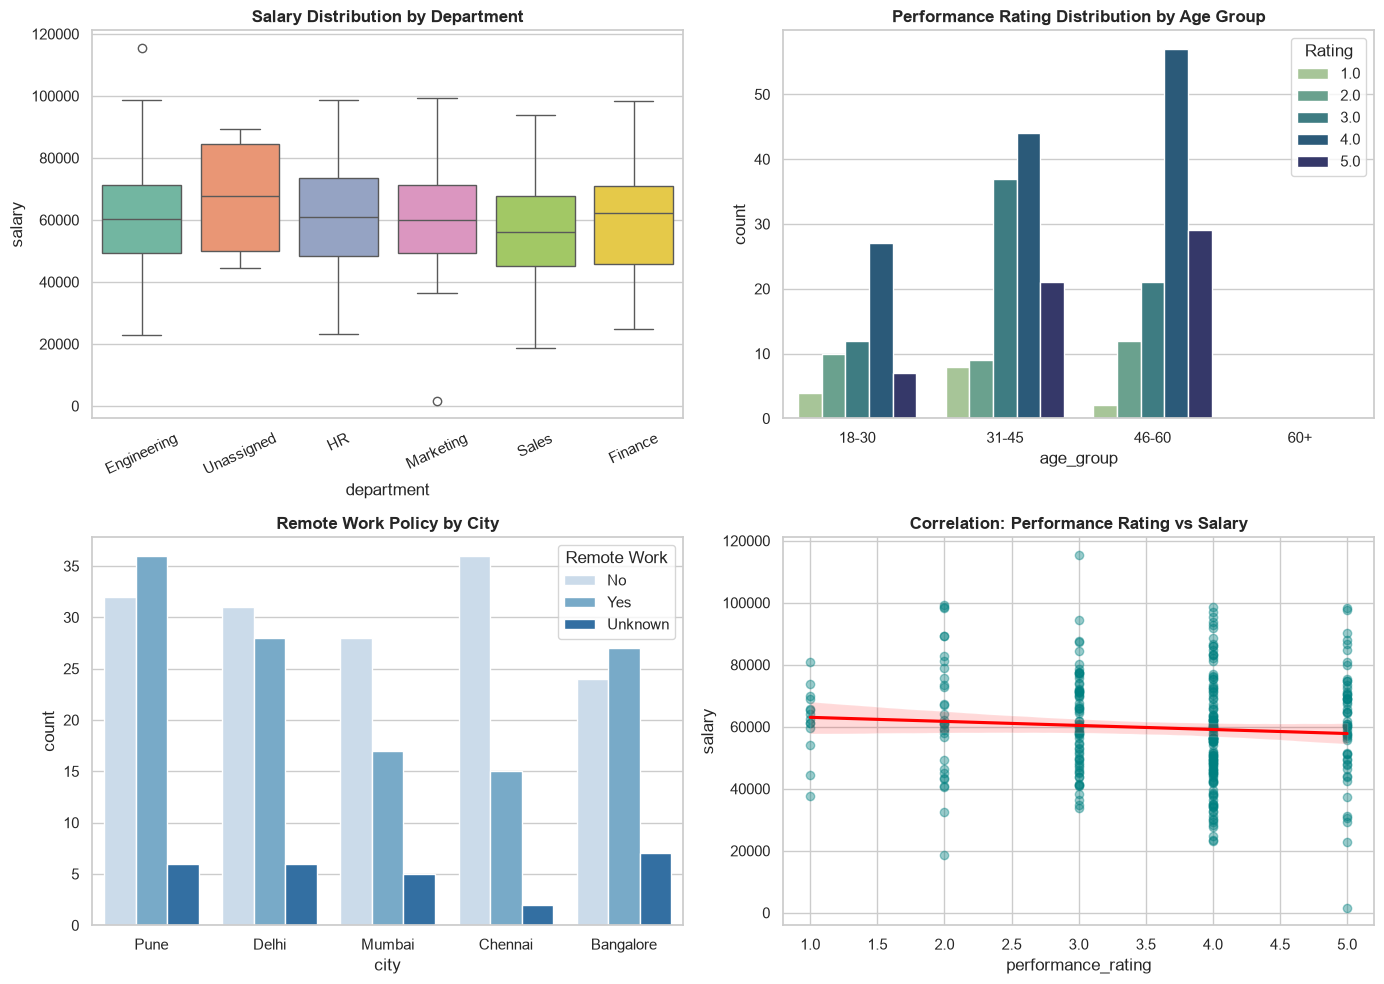

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Statistical Summary
print("--- Numerical Summary ---")
print(df[['salary', 'age', 'tenure_years', 'performance_rating']].describe().round(2))

# 2. Visualizations Grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot A: Salary Distribution by Department
sns.boxplot(ax=axes[0, 0], data=df, x='department', y='salary', palette='Set2')
axes[0, 0].set_title('Salary Distribution by Department', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=25)

# Plot B: Performance Rating by Age Group
sns.countplot(ax=axes[0, 1], data=df, x='age_group', hue='performance_rating', palette='crest')
axes[0, 1].set_title('Performance Rating Distribution by Age Group', fontweight='bold')
axes[0, 1].legend(title='Rating', loc='upper right')

# Plot C: Remote Work Count by City
sns.countplot(ax=axes[1, 0], data=df, x='city', hue='remote_work', palette='Blues')
axes[1, 0].set_title('Remote Work Policy by City', fontweight='bold')
axes[1, 0].legend(title='Remote Work')

# Plot D: Salary vs Performance Rating (with regression trend)
sns.regplot(ax=axes[1, 1], data=df, x='performance_rating', y='salary', 
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
axes[1, 1].set_title('Correlation: Performance Rating vs Salary', fontweight='bold')

plt.tight_layout()
plt.show()

In [64]:
total_headcount =len(df)
avg_salary = df['salary'].mean()
median_age = df['age'].median()
high_performer_rate= (df['performance_rating'] >= 4).mean() * 100
remote_ratio =(df['remote_work'] == 'Yes').mean()*100

print(f"Total Headcount : {total_headcount}")
print(f"Average Compensation: ₹{avg_salary:,.2f}")
print(f"Median Age:{median_age:.0f} years")
print(f"High Performance Ratio (Rating>=4):{high_performer_rate:.1f}%")
print(f"Fully Remote Workforce: {remote_ratio:.1f}%")


Total Headcount : 300
Average Compensation: ₹59,624.73
Median Age:42 years
High Performance Ratio (Rating>=4):61.7%
Fully Remote Workforce: 41.0%
